# Train Classifiers

In notebook `06-Search_for_S2_Images` we prepared the ground to train SKLEARN classifiers. Here, we already have the reflectances, ndwi and mndwi saved as `parquet`. Additionally, we have the points samples, also as a parquet. Let's open these dataframes first.

## Open Dataframes

In [1]:
import geopandas as gpd
import pandas as pd
import rioxarray as xrio

In [ ]:
img = (
    xrio.open_rasterio("/data/swot/geotiffs/s2_curua-una-20240927T135701_4326.tif")
    .sel(band=1)
    .squeeze()
)
img

<xarray.DataArray (y: 5951, x: 5746)> Size: 137MB
[34194446 values with dtype=float32]
Coordinates:
    band         int64 8B 1
  * x            (x) float64 46kB -54.75 -54.75 -54.75 ... -54.24 -54.24 -54.23
  * y            (y) float64 48kB -2.73 -2.73 -2.731 ... -3.267 -3.267 -3.267
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     nan
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('B04', 'B03', 'B02', 'B08', 'B11', 'B12', 'SCL')

In [277]:
points = gpd.read_file(
    "/data/swot/geotiffs/points/s2_curua-una-20240927T135701_samples.shp",
)

points["x"] = points.geometry.x
points["y"] = points.geometry.y
points = points.set_index(["x", "y"])
points

,,class,geometry
x,y,,
-54.420725,-3.244779,0.0,POINT (-54.42072 -3.24478)
-54.497803,-3.012823,0.0,POINT (-54.4978 -3.01282)
-54.493836,-3.219897,0.0,POINT (-54.49384 -3.2199)
-54.453449,-2.752470,0.0,POINT (-54.45345 -2.75247)
-54.552614,-2.773024,0.0,POINT (-54.55261 -2.77302)
...,...,...,...
-54.595964,-3.042672,0.0,POINT (-54.59596 -3.04267)
-54.596253,-3.042847,0.0,POINT (-54.59625 -3.04285)
-54.594625,-3.040773,0.0,POINT (-54.59462 -3.04077)


In [4]:
reflectances = pd.read_parquet("/data/swot/geotiffs/points/s2_curua-una-reflectances_df.parquet")

In [281]:
reflectances["ndwi"] = (reflectances["B03"] - reflectances["B08"]) / (
    reflectances["B03"] + reflectances["B08"]
)
reflectances["mndwi"] = (reflectances["B03"] - reflectances["B11"]) / (
    reflectances["B03"] + reflectances["B11"]
)

reflectances["ndvi"] = (reflectances["B08"] - reflectances["B04"]) / (
    reflectances["B08"] + reflectances["B04"]
)
reflectances

,,B04,B03,B02,B08,B11,B12,ndwi,mndwi,ndvi
x,y,,,,,,,,,
-54.752837,-2.730384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-54.752747,-2.730384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-54.752656,-2.730384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-54.752566,-2.730384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-54.752476,-2.730384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
-54.235286,-3.266775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-54.235196,-3.266775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-54.235106,-3.266775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Sample points

To sample the points, we need to align the points and the coordinates of the reflectances dataframe. The solution is to use nearest from cKDTree. 

In [89]:
from scipy.spatial import cKDTree

In [282]:
reflect_cords = reflectances.reset_index()[["x", "y"]].values
# 2. Build KDTree on reflectance grid
tree = cKDTree(reflect_cords)


In [283]:
points_cords = points.reset_index()[["x", "y"]].values

In [ ]:
# 3. For each point, find index of nearest reflectance pixel
_, idx = tree.query(points_cords, k=1)  # idx is array of indices into reflectances

In [285]:
# train_df = reflectances.loc[points.index]
train_df = reflectances.reset_index().iloc[idx].reset_index(drop=True)

In [286]:
train_df = train_df.set_index(["x", "y"])

In [287]:
train_df["class"] = points["class"].values

In [288]:
train_df

,,B04,B03,B02,B08,B11,B12,ndwi,mndwi,ndvi,class
x,y,,,,,,,,,,
-54.420725,-3.244779,0.1293,0.1510,0.1320,0.4184,0.2836,0.1767,-0.469617,-0.305108,0.527844,0.0
-54.497803,-3.012823,0.1752,0.1858,0.1640,0.3896,0.3475,0.2244,-0.354188,-0.303206,0.379603,0.0
-54.493836,-3.219897,0.1359,0.1618,0.1349,0.4600,0.3077,0.1932,-0.479575,-0.310756,0.543883,0.0
-54.453449,-2.752470,0.1348,0.1602,0.1354,0.4584,0.2921,0.1838,-0.482056,-0.291621,0.545516,0.0
-54.552614,-2.773024,0.2598,0.2332,0.1969,0.3866,0.4804,0.3120,-0.247499,-0.346413,0.196163,0.0
...,...,...,...,...,...,...,...,...,...,...,...
-54.595976,-3.042663,0.3282,0.2872,0.2376,0.4608,0.4495,0.2869,-0.232086,-0.220307,0.168061,0.0
-54.596246,-3.042843,0.3032,0.2760,0.2228,0.4612,0.4024,0.2595,-0.251221,-0.186321,0.206698,0.0
-54.594624,-3.040770,0.3250,0.2946,0.2328,0.4764,0.4552,0.2818,-0.235798,-0.214190,0.188919,0.0


## Train Classifier

In [289]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


In [290]:
feature_cols = ["B04", "B03", "B02", "B08", "B11", "B12", "ndwi", "mndwi", "ndvi"]
# feature_cols = ["B08", "B12", "ndwi", "mndwi"]


In [291]:
train_df = train_df.dropna()
len(train_df)

382

In [292]:
X = train_df[feature_cols].values
y = train_df["class"].values

X.shape, y.shape

((382, 9), (382,))

In [293]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [251]:
# 2. Split data into train/test (e.g. 70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42,
)

In [297]:
clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
X_train = X_scaled
y_train = y
# clf = GaussianNB()
# clf = SVC(kernel='rbf', C=0.9, gamma='scale', random_state=42)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_train)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.96      0.95       137
         1.0       0.98      0.94      0.96       104
         2.0       0.92      0.94      0.93       141

    accuracy                           0.95       382
   macro avg       0.95      0.95      0.95       382
weighted avg       0.95      0.95      0.95       382



In [298]:
reflectances_scaled = scaler.transform(reflectances[feature_cols].fillna(0).values)

In [299]:
full_pred = clf.predict(reflectances_scaled)

In [300]:
full_pred = full_pred.reshape(img.shape[0], img.shape[1])

In [327]:
pred_img = img.where(img.isnull(), full_pred)

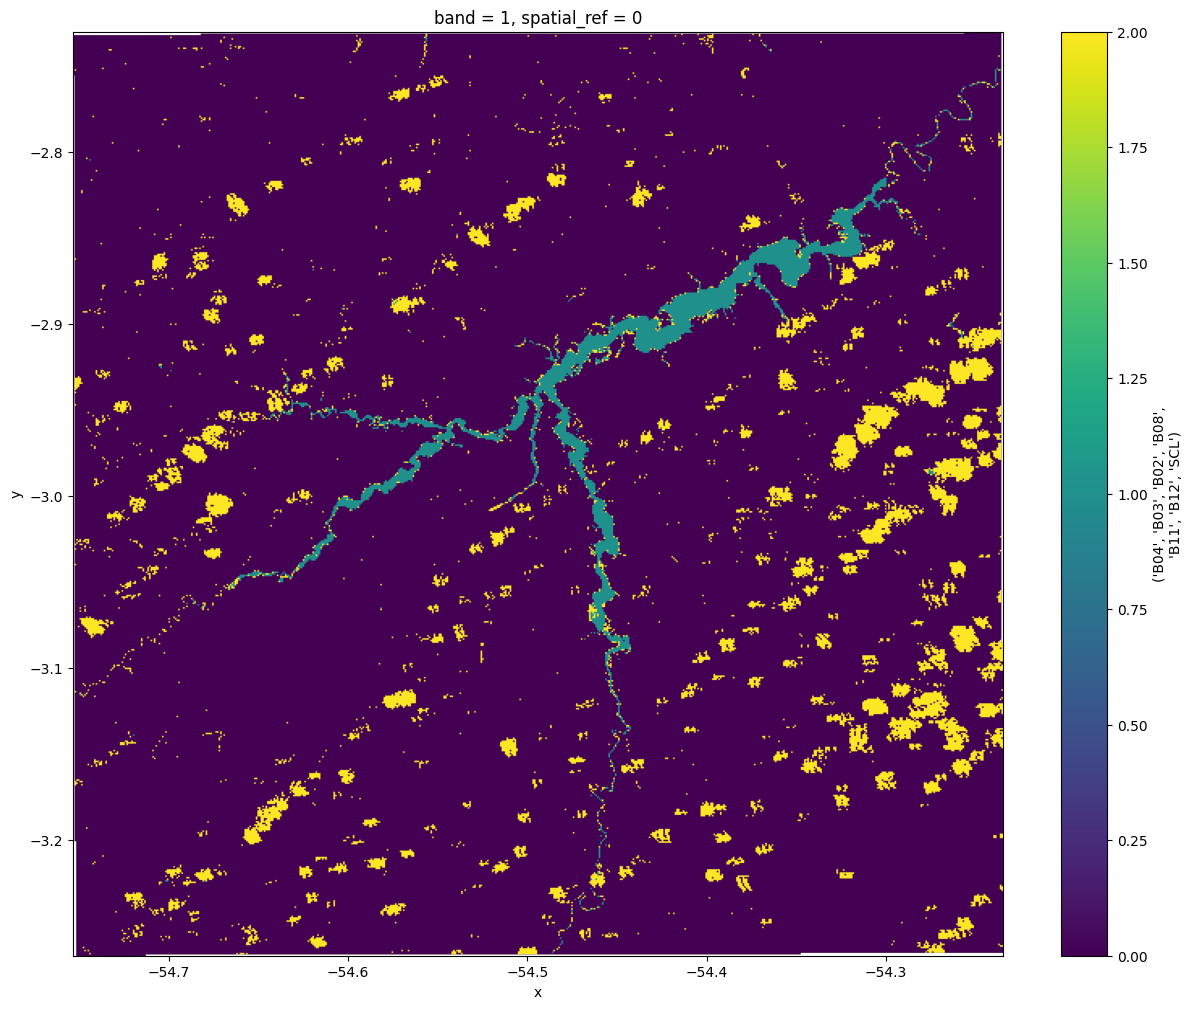

In [328]:
pred_img.isel(x=slice(None, None, 10), y=slice(None, None, 10)).plot.imshow(
    figsize=(15, 12), interpolation="antialiased"
)

In [304]:
pred_img = pred_img.fillna(2).astype("uint8")
pred_img = pred_img.rio.write_nodata(2)
pred_img.attrs["long_name"] = "Classification"
pred_img


<xarray.DataArray (y: 5951, x: 5746)> Size: 34MB
array([[2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       ...,
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2]], shape=(5951, 5746), dtype=uint8)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 46kB -54.75 -54.75 -54.75 ... -54.24 -54.24 -54.23
  * y            (y) float64 48kB -2.73 -2.73 -2.731 ... -3.267 -3.267 -3.267
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     2
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      Classification

In [305]:
pred_img.rio.to_raster(
    "/data/swot/geotiffs/s2_curua-una-20240927T135701_ref_mask_rf3.tif",
    compression="DEFLATE",
)

## Post-processing

In [335]:
from skimage.morphology import binary_opening, closing, disk, opening, remove_small_objects, dilation


In [308]:
cls = pred_img.data.copy()

In [ ]:
# Binary masks for the classes you want to clean
mask_water = cls == 1
mask_cloud = cls == 2

# Remove small clusters (<4 pixels)
clean_water = remove_small_objects(mask_water, min_size=5, connectivity=1)
clean_cloud = remove_small_objects(mask_cloud, min_size=5, connectivity=1)
clean_cloud = binary_opening(clean_cloud, disk(2))

In [ ]:
dilated_water = dilation(clean_water, disk(1))

In [331]:
cls_clean = cls.copy()
# Set removed small components back to background or a null code, e.g., 0
cls_clean[mask_water & ~clean_water] = 0
cls_clean[mask_cloud & ~clean_cloud] = 0

In [332]:
pred_img.data = cls_clean

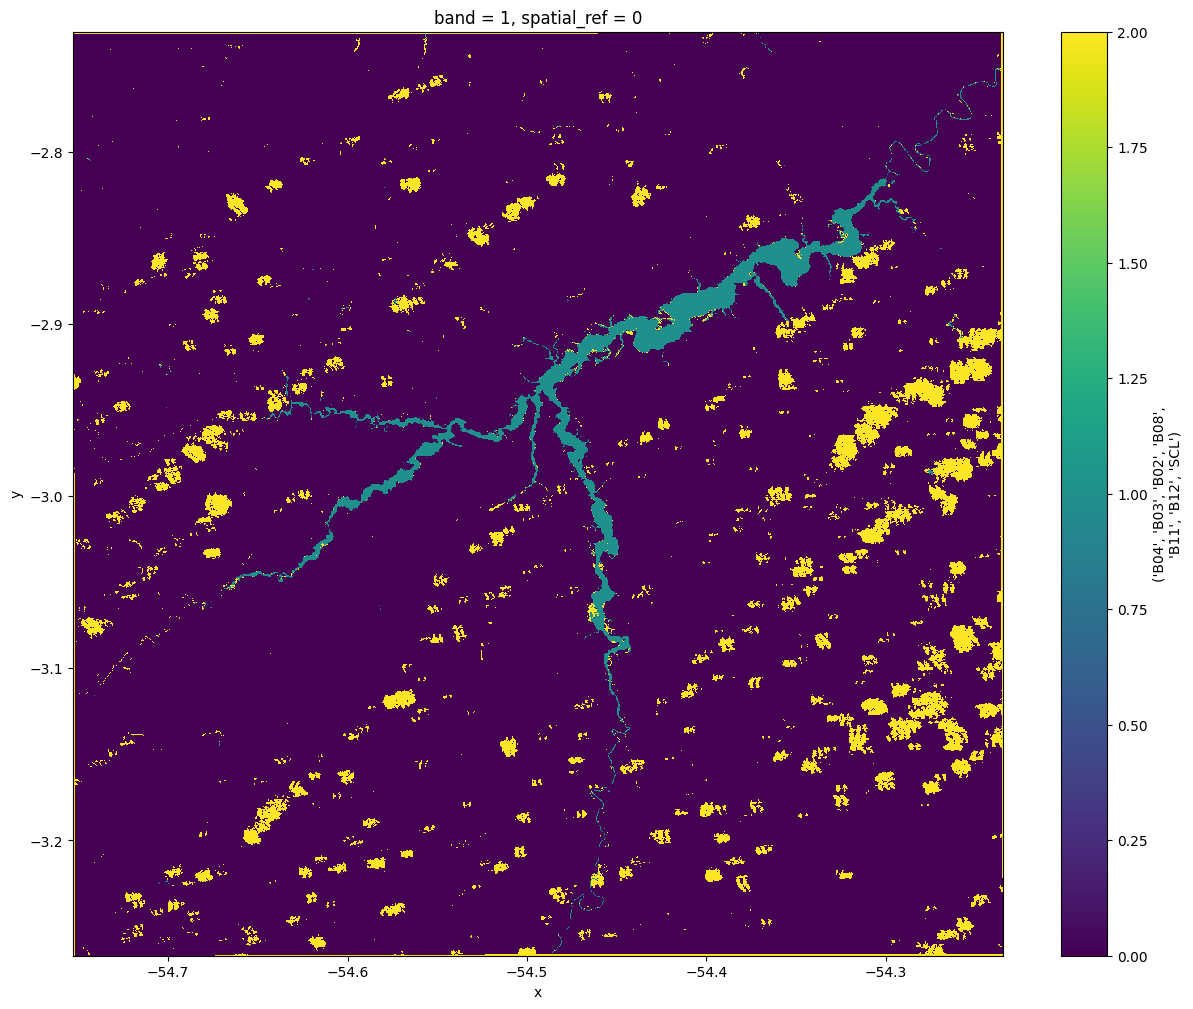

In [334]:
pred_img.isel(x=slice(None, None, 5), y=slice(None, None, 5)).plot.imshow(
    figsize=(15, 12)
)

In [337]:
pred_img = pred_img.fillna(2).astype("uint8")
pred_img = pred_img.rio.write_nodata(2)
pred_img.attrs["long_name"] = "Classification"

pred_img.rio.to_raster(
    "/data/swot/geotiffs/s2_curua-una-20240927T135701_ref_mask_rf3_clean.tif",
    compression="DEFLATE",
)

In [338]:
water_mask = pred_img.copy()

In [339]:
import numpy as np
water_mask.data = np.where(water_mask.data == 1, 1, 0).astype("uint8")

In [340]:
pred_img.rio.to_raster(
    "/data/swot/geotiffs/s2_curua-una-20240927T135701_ref_mask_rf3_binary.tif",
    compression="DEFLATE",
)